In [1]:
import cv2
print(cv2.__version__)

5.0.0


In [3]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 229.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.4 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO
print("YOLO Installed")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO Installed


In [5]:
from google.colab import files

uploaded = files.upload()

Saving pedestrain.jpg to pedestrain.jpg



0: 448x640 2 persons, 5 cars, 1 truck, 1 skateboard, 389.1ms
Speed: 16.5ms preprocess, 389.1ms inference, 38.2ms postprocess per image at shape (1, 3, 448, 640)
Detection Completed


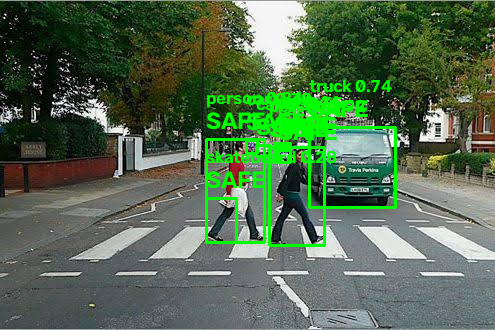

In [6]:
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# Load YOLO model
model = YOLO("yolov8n.pt")

# Read image
image = cv2.imread("pedestrain.jpg")   # Change this if your filename is different

if image is None:
    print("Image not found!")
else:
    # Run detection
    results = model(image)

    output = image.copy()

    for result in results:
        for box in result.boxes:

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            confidence = float(box.conf[0])
            class_id = int(box.cls[0])
            label = model.names[class_id]

            width = x2 - x1
            height = y2 - y1
            area = width * height

            if area > 120000:
                warning = "STOP!"
                color = (0, 0, 255)

            elif area > 60000:
                warning = "BRAKE NOW"
                color = (0, 140, 255)

            elif area > 25000:
                warning = "SLOW DOWN"
                color = (0, 255, 255)

            else:
                warning = "SAFE"
                color = (0, 255, 0)

            cv2.rectangle(output, (x1, y1), (x2, y2), color, 2)

            cv2.putText(output,
                        f"{label} {confidence:.2f}",
                        (x1, y1 - 35),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        color,
                        2)

            cv2.putText(output,
                        warning,
                        (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.8,
                        color,
                        2)

    print("Detection Completed")
    cv2_imshow(output)